Classes found: ['close', 'open']

Image Count Per Class:
close: 73088 images (47.47%)
open: 80872 images (52.53%)

Total Images: 153960


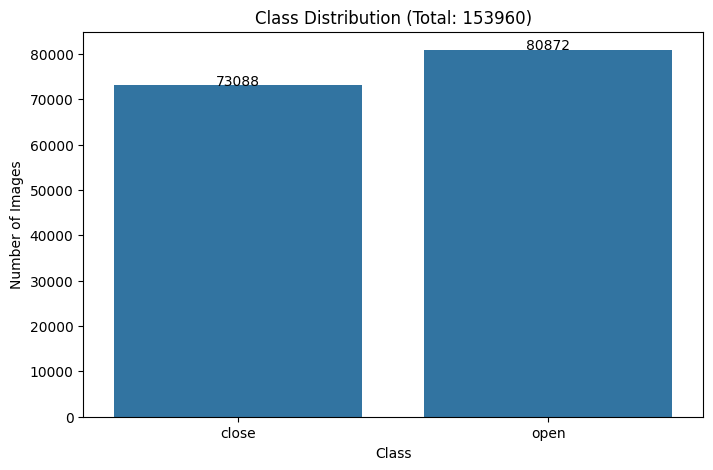


File Extensions Found:
.jpg: 153960 files (100.00%)


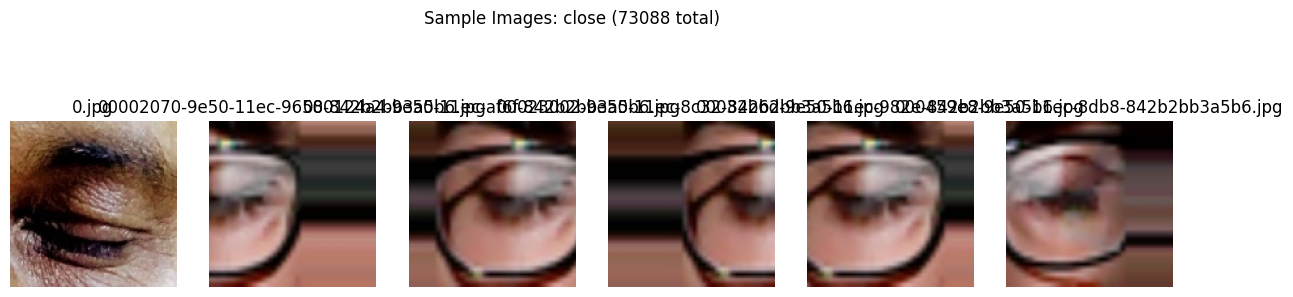

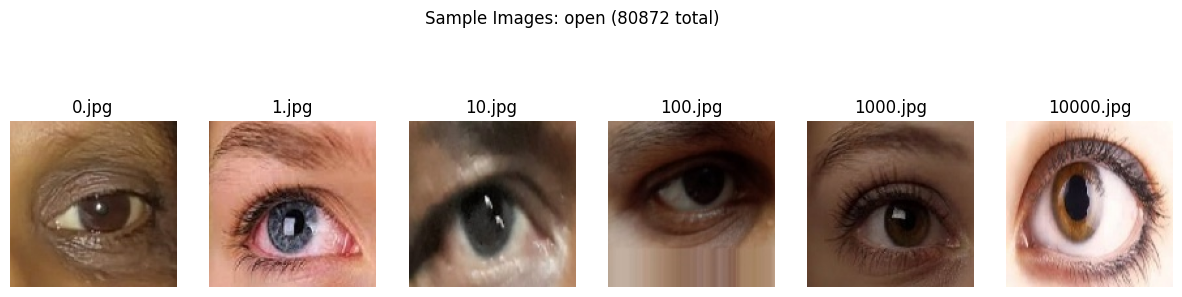


=== IMAGE DIMENSION STATISTICS ===
Width:  min=128, max=128, mean=128.00, std=0.00
Height: min=128, max=128, mean=128.00, std=0.00
All images are same size: 128x128

Aspect Ratio: min=1.000, max=1.000, mean=1.000


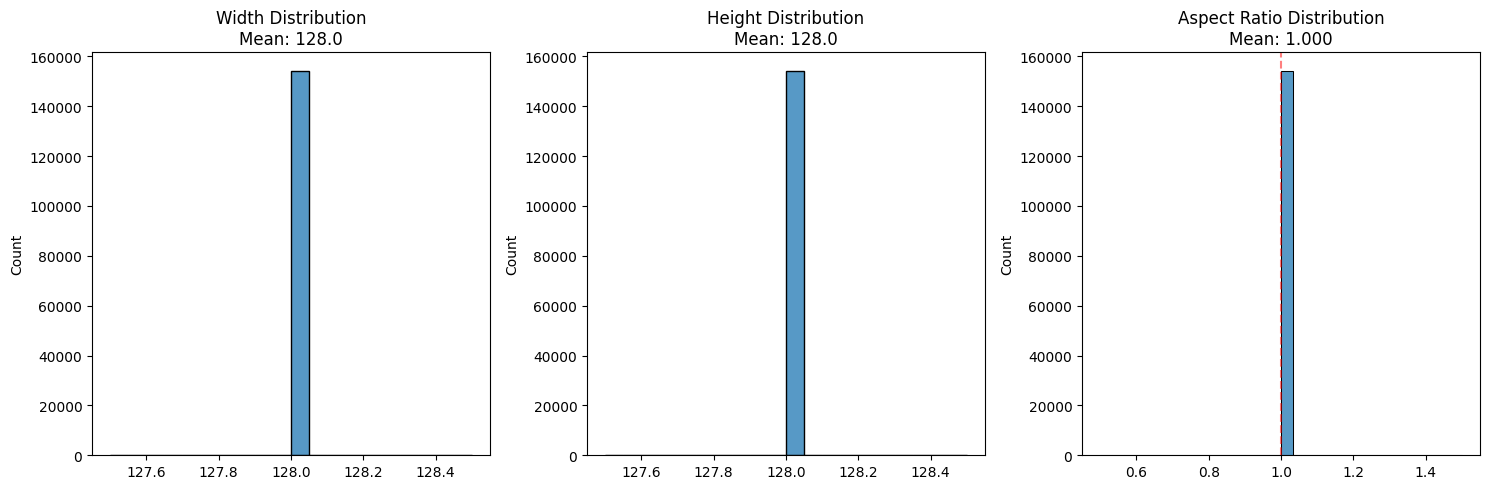


=== BRIGHTNESS ANALYSIS ===
Brightness: min=5.8, max=233.1, mean=102.7
Contrast (std): min=3.1, max=82.3, mean=39.4

Too dark (<30): 2465 images (1.60%)
Too bright (>220): 31 images (0.02%)


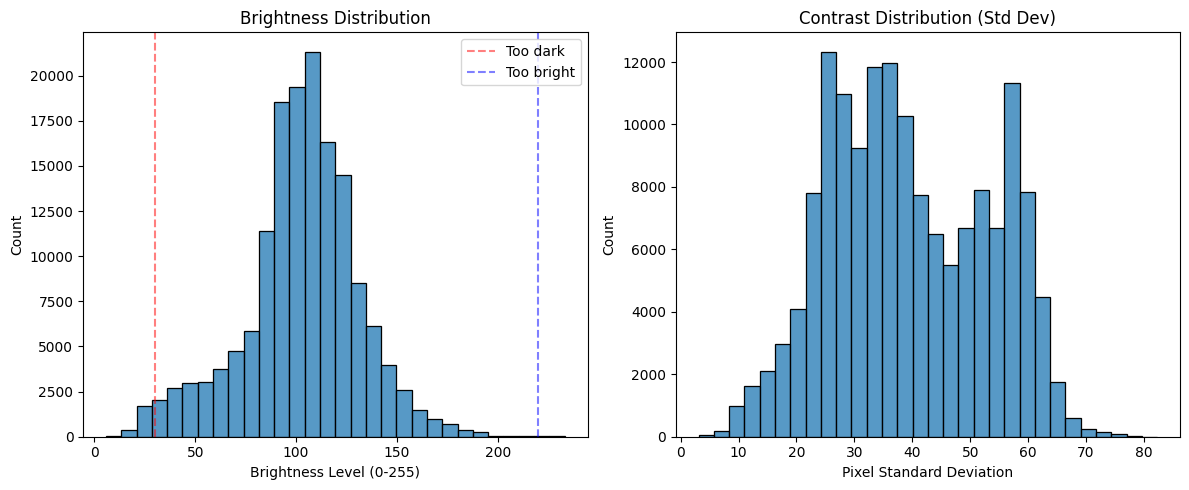


=== COLOR CHANNEL CHECK ===
Color channels found: {3}
All sampled images have 3 channel(s)

=== CORRUPTED IMAGES CHECK ===
Corrupted Images Found: 0

=== DUPLICATE CHECK ===
Checking for potential duplicate images (this may take a while)...
Checked 400 unique images
Possible duplicates found: 0

DATASET SUMMARY
Classes: close, open
Total images: 153960
Image size range: 128x128 to 128x128
Common size: 128x128
Brightness range: 6-233
Corrupted images: 0 (0.00%)
Class balance ratio: 1.11:1


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import hashlib

# --------------------------
# SET YOUR DATASET PATH HERE
# --------------------------
dataset_path = "D:/Real_Dataset/Image"   # example: "DrowsinessDataset/"

# Get class folders
classes = os.listdir(dataset_path)
print("Classes found:", classes)

# --------------------------
# 1. COUNT IMAGES PER CLASS
# --------------------------
image_counts = {}

for cls in classes:
    path = os.path.join(dataset_path, cls)
    image_counts[cls] = len(os.listdir(path))

print("\nImage Count Per Class:")
total_images = sum(image_counts.values())
for k, v in image_counts.items():
    percentage = (v / total_images) * 100
    print(f"{k}: {v} images ({percentage:.2f}%)")

print(f"\nTotal Images: {total_images}")

# Bar Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()))
plt.title(f"Class Distribution (Total: {total_images})")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add value labels on bars
for i, v in enumerate(image_counts.values()):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

# --------------------------
# 2. FILE FORMAT ANALYSIS
# --------------------------
extensions = {}
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder):
        ext = os.path.splitext(img_name)[1].lower()
        extensions[ext] = extensions.get(ext, 0) + 1

print("\nFile Extensions Found:")
for ext, count in extensions.items():
    print(f"{ext}: {count} files ({(count/total_images)*100:.2f}%)")

# --------------------------
# 3. SHOW SAMPLE IMAGES
# --------------------------
def show_samples(class_name, count=6):
    folder = os.path.join(dataset_path, class_name)
    images = os.listdir(folder)

    plt.figure(figsize=(15, 4))
    for i in range(min(count, len(images))):
        img = Image.open(os.path.join(folder, images[i]))
        plt.subplot(1, count, i+1)
        plt.imshow(img)
        plt.title(f"{images[i]}")
        plt.axis("off")
    plt.suptitle(f"Sample Images: {class_name} ({len(images)} total)")
    plt.show()

for c in classes:
    show_samples(c)

# --------------------------
# 4. IMAGE SIZE DISTRIBUTION
# --------------------------
widths = []
heights = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
        except:
            pass

# Summary statistics
print("\n=== IMAGE DIMENSION STATISTICS ===")
print(f"Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.2f}, std={np.std(widths):.2f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.2f}, std={np.std(heights):.2f}")

# Check if all images are same size
if len(set(widths)) == 1 and len(set(heights)) == 1:
    print(f"All images are same size: {widths[0]}x{heights[0]}")
else:
    print("Images have varying dimensions")

# Aspect ratio analysis
aspect_ratios = [w/h for w, h in zip(widths, heights)]
print(f"\nAspect Ratio: min={min(aspect_ratios):.3f}, max={max(aspect_ratios):.3f}, mean={np.mean(aspect_ratios):.3f}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Width distribution
sns.histplot(widths, bins=20, ax=axes[0])
axes[0].set_title(f"Width Distribution\nMean: {np.mean(widths):.1f}")

# Height distribution
sns.histplot(heights, bins=20, ax=axes[1])
axes[1].set_title(f"Height Distribution\nMean: {np.mean(heights):.1f}")

# Aspect ratio distribution
sns.histplot(aspect_ratios, bins=30, ax=axes[2])
axes[2].set_title(f"Aspect Ratio Distribution\nMean: {np.mean(aspect_ratios):.3f}")
axes[2].axvline(1.0, color='red', linestyle='--', alpha=0.5, label='Square (1:1)')

plt.tight_layout()
plt.show()

# --------------------------
# 5. BRIGHTNESS ANALYSIS
# --------------------------
brightness = []
contrast = []  # Added contrast analysis

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                brightness.append(np.mean(img))
                contrast.append(np.std(img))  # Standard deviation as contrast measure
        except:
            pass

# Brightness statistics
bright_arr = np.array(brightness)
print("\n=== BRIGHTNESS ANALYSIS ===")
print(f"Brightness: min={bright_arr.min():.1f}, max={bright_arr.max():.1f}, mean={bright_arr.mean():.1f}")
print(f"Contrast (std): min={min(contrast):.1f}, max={max(contrast):.1f}, mean={np.mean(contrast):.1f}")

# Identify potential issues
too_dark = np.sum(bright_arr < 30)
too_bright = np.sum(bright_arr > 220)
print(f"\nToo dark (<30): {too_dark} images ({(too_dark/len(bright_arr))*100:.2f}%)")
print(f"Too bright (>220): {too_bright} images ({(too_bright/len(bright_arr))*100:.2f}%)")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Brightness distribution
sns.histplot(brightness, bins=30, ax=axes[0])
axes[0].axvline(30, color='red', linestyle='--', alpha=0.5, label='Too dark')
axes[0].axvline(220, color='blue', linestyle='--', alpha=0.5, label='Too bright')
axes[0].set_title("Brightness Distribution")
axes[0].set_xlabel("Brightness Level (0-255)")
axes[0].legend()

# Contrast distribution
sns.histplot(contrast, bins=30, ax=axes[1])
axes[1].set_title("Contrast Distribution (Std Dev)")
axes[1].set_xlabel("Pixel Standard Deviation")

plt.tight_layout()
plt.show()

# --------------------------
# 6. COLOR CHANNEL CHECK
# --------------------------
color_channels = set()
sample_count = min(100, total_images)  # Check a sample

print("\n=== COLOR CHANNEL CHECK ===")
for cls in classes[:2]:  # Check first 2 classes
    folder = os.path.join(dataset_path, cls)
    images = os.listdir(folder)[:sample_count//2]
    for img_name in images:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            color_channels.add(img.shape[2] if len(img.shape) == 3 else 1)

print(f"Color channels found: {color_channels}")
if len(color_channels) == 1:
    print(f"All sampled images have {next(iter(color_channels))} channel(s)")
else:
    print("Warning: Images have different color channels!")

# --------------------------
# 7. CHECK FOR CORRUPTED IMAGES
# --------------------------
corrupted_images = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  # Verify integrity
            
            # Also try to open with cv2
            cv2_img = cv2.imread(img_path)
            if cv2_img is None:
                raise Exception("CV2 cannot read")
                
        except Exception as e:
            corrupted_images.append((img_path, str(e)))

print("\n=== CORRUPTED IMAGES CHECK ===")
print(f"Corrupted Images Found: {len(corrupted_images)}")
if corrupted_images:
    for c, err in corrupted_images[:5]:  # Show first 5
        print(f"  - {os.path.basename(c)}: {err}")
    if len(corrupted_images) > 5:
        print(f"  ... and {len(corrupted_images)-5} more")

# --------------------------
# 8. QUICK DUPLICATE CHECK (HASH-BASED)
# --------------------------
print("\n=== DUPLICATE CHECK ===")
print("Checking for potential duplicate images (this may take a while)...")

hashes = {}
possible_duplicates = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    image_list = os.listdir(folder)[:200]  # Limit for speed
    
    for img_name in image_list:
        img_path = os.path.join(folder, img_name)
        try:
            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
                
            if file_hash in hashes:
                possible_duplicates.append((img_path, hashes[file_hash]))
            else:
                hashes[file_hash] = img_path
        except:
            pass

print(f"Checked {len(hashes)} unique images")
print(f"Possible duplicates found: {len(possible_duplicates)}")
if possible_duplicates:
    print("Sample duplicate pairs:")
    for dup1, dup2 in possible_duplicates[:3]:
        print(f"  - {os.path.basename(dup1)} <-> {os.path.basename(dup2)}")

# --------------------------
# 9. DATASET SUMMARY
# --------------------------
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Classes: {', '.join(classes)}")
print(f"Total images: {total_images}")
print(f"Image size range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
print(f"Common size: {np.median(widths):.0f}x{np.median(heights):.0f}")
print(f"Brightness range: {bright_arr.min():.0f}-{bright_arr.max():.0f}")
print(f"Corrupted images: {len(corrupted_images)} ({(len(corrupted_images)/total_images)*100:.2f}%)")
print(f"Class balance ratio: {max(image_counts.values())/min(image_counts.values()):.2f}:1")
print("="*50)